# GENIE vs production: νμ CC event rates (truth / mcnu only)

Compare **νμ CC**, **νμ CCQE**, and **νμ CC 1p0π signal** event rates between GENIE standalone flat ROOT and production MC truth (`mcnu` + `hdr` only).

No reco — just truth counts and $E_\nu$ shapes.

- **GENIE (CC)**: `14_1000180400_CC_*.flat.root` — `PDGnu==14 & cc==1`.
- **GENIE (CCQE)**: same file with `Mode==1` (QE channel).
- **GENIE (1p0π signal)**: νμ CC + 1μ1p0π topology (highest-$p$ leading μ/p; **no vertex FV** on flat files; no μ/p end positions for per-TPC FV).
- **Production (CC)**: `(mc.iscc==1) & (mc.pdg==14)` on `mcnu`.
- **Production (CCQE)**: CC cut plus `mc.genie_mode==0`.
- **Production (1p0π signal)**: `categories.IsNuInFV_NumuCC_1p0pi` (default `signal_truth_fv='per_tpc'`).
- **Rate** = $N / \mathrm{POT}$.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import uproot
from os import path

%matplotlib inline
import matplotlib.pyplot as plt

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')
from pyanalib.split_df_helpers_new import dfs_from_dir
from makedf.util import InFV
from analysis_village.numucc_1p0pi.categories import (
    IsNuInFV_NumuCC_1p0pi,
    IsTruthCC1p0piPerTPCFV,
)

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)


## Configuration


In [ ]:
# GENIE standalone flat ROOT (CC νμ on Ar)
genie_file_dir = "/pnfs/sbnd/persistent/users/apapadop/GENIETweakedSamples/v3_6_2_AR23_20i_00_000_gen1_flux"
genie_filename = genie_file_dir + "/14_1000180400_CC_v3_6_2_AR23_20i_00_000.flat.root"
# genie_filename = "/pnfs/sbnd/scratch/users/sungbino/pac/xsec_charge/AR23_20i_00_000/gntp-numu-8.flat.root"

# Production MC truth (mcnu + hdr only)
mc_df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/merged_perTPC"
mc_filename_str = "sel_mup"

# Vertex FV strip shared with production pre-selection
FLAT_ALIGNED_X_CM = 10.0
SIGNAL_TRUTH_FV = "per_tpc"  # categories.IsNuInFV_NumuCC_1p0pi default


## Load GENIE flat ROOT


In [ ]:
events = uproot.open(genie_filename + ":FlatTree_VARS")
genie_arr = events.arrays(
    ["PDGnu", "cc", "dpt", "Mode", "Enu_true", "fScaleFactor", "Weight"], library="np"
)

In [ ]:
genie_cc = (genie_arr["PDGnu"] == 14) & (genie_arr["cc"] == 1)
genie_enu = genie_arr["Enu_true"][genie_cc]
genie_w = (40.0 * genie_arr["fScaleFactor"] * genie_arr["Weight"])[genie_cc]

print(f"GENIE flat: {len(genie_arr['Enu_true']):,} entries, {genie_cc.sum():,} νμ CC")
print(f"  Enu range: {genie_enu.min():.3f} – {genie_enu.max():.3f} GeV")
print(f"  fScaleFactor unique: {np.unique(genie_arr['fScaleFactor']).size}")
print(f"  Weight unique: {np.unique(genie_arr['Weight']).size}")
print(f"  sum(weights) νμ CC: {genie_w.sum():.6e}")

## Load production MC (mcnu + hdr only)


In [ ]:
df_mc = dfs_from_dir(
    search_dir=mc_df_dir,
    filename_str=mc_filename_str,
    keys2load=["hdr", "mcnu"],
    n_max_concat=10,
)
mc_hdr_df = df_mc["hdr"]
mc_nu_df = df_mc["mcnu"] #.groupby(level=[0,1]).head(1)

In [ ]:
mc_hdr_df = df_mc["hdr"]
mc_nu_df = df_mc["mcnu"] #.groupby(level=[0,1]).head(1)

In [8]:
# FV CUT (vertex in SBND_nohighyz + |x|>10 cm — matches GENIE flat vertex selection)
mc_nu_df = mc_nu_df[InFV(mc_nu_df.mc.position, det="SBND_nohighyz")]
mc_nu_df = mc_nu_df[np.abs(mc_nu_df.mc.position.x) > FLAT_ALIGNED_X_CM]

mc_tot_pot = mc_hdr_df["pot"].sum()
print(f"Production: {len(mc_nu_df):,} mcnu rows")
print(f"  Total POT: {mc_tot_pot:.3e}")

mc_cc = (mc_nu_df["mc"]["iscc"] == 1) & (mc_nu_df["mc"]["pdg"] == 14)
mc_cc = mc_cc & mc_nu_df["mc"]["iscc"].notna() & mc_nu_df["mc"]["pdg"].notna()
prod_enu = np.asarray(mc_nu_df.loc[mc_cc, ("mc", "E")], dtype=float)

print(f"  νμ CC rows: {mc_cc.sum():,}")
print(f"  Enu range: {prod_enu.min():.3f} – {prod_enu.max():.3f} GeV")

Production: 1,613,662 mcnu rows
  Total POT: 2.819e+20
  νμ CC rows: 1,135,894
  Enu range: 0.135 – 6.758 GeV


In [ ]:
mc_nu_df.del_Tp

## νμ CC event rates


In [9]:
n_genie_cc = int(genie_cc.sum())
n_prod_cc = int(mc_cc.sum())

rate_genie = n_genie_cc  # GENIE flat has no POT in file; count is per generated sample
rate_prod_per_pot = n_prod_cc / mc_tot_pot

print("=== νμ CC counts ===")
print(f"  GENIE flat (generated sample):  {n_genie_cc:,}")
print(f"  Production mcnu:                {n_prod_cc:,}")
print(f"  Ratio prod/GENIE:               {n_prod_cc / n_genie_cc:.4f}")
print()
print("=== Production rate ===")
print(f"  N_νμCC / POT = {rate_prod_per_pot:.6e} [/POT]")
print(f"  N_νμCC per 10^20 POT = {rate_prod_per_pot * 1e20:.4f}")
print()
print("GENIE flat file encodes exposure in fScaleFactor (constant per file).")
print(f"  GENIE sum(40×fScaleFactor×Weight) = {genie_w.sum():.6e}")


=== νμ CC counts ===
  GENIE flat (generated sample):  1,000,000
  Production mcnu:                1,135,894
  Ratio prod/GENIE:               1.1359

=== Production rate ===
  N_νμCC / POT = 4.029347e-15 [/POT]
  N_νμCC per 10^20 POT = 402934.7188

GENIE flat file encodes exposure in fScaleFactor (constant per file).
  GENIE sum(40×fScaleFactor×Weight) = 2.413641e-37


Fiducial volume (FV_split_truncY): $10<|x|<190$: $|y|<190$ ($10<z<250$), $-190<y<100$ ($250<z<450$)
Cathode inset: 10 cm
  slab 1: x=(-190.0, -10.0) cm, y=(-190.0, 190.0) cm, z=(10.0, 250.0) cm -> 1.6416e+07 cm³
  slab 2: x=(10.0, 190.0) cm, y=(-190.0, 190.0) cm, z=(10.0, 250.0) cm -> 1.6416e+07 cm³
  slab 3: x=(-190.0, -10.0) cm, y=(-190.0, 100.0) cm, z=(250.0, 450.0) cm -> 1.0440e+07 cm³
  slab 4: x=(10.0, 190.0) cm, y=(-190.0, 100.0) cm, z=(250.0, 450.0) cm -> 1.0440e+07 cm³
V_SBND = 5.371200e+07 cm³
Integrated flux: 1.518e-08
Integrated flux × POT = 4.279354e+12 ν/cm²
# argon target nuclei: 1.1203e+30
XSEC_UNIT = 2.085959e-43 cm²/nucleon


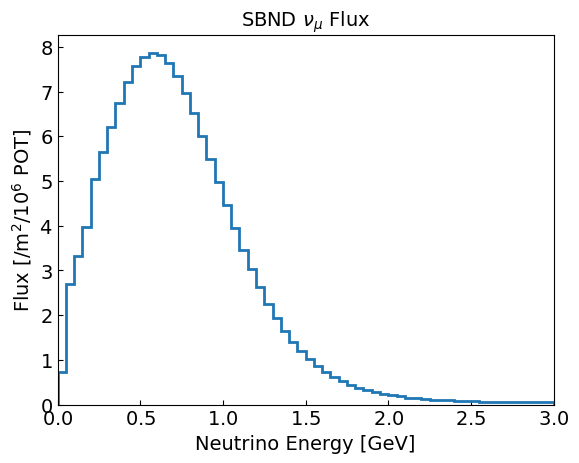

In [13]:
# --- rate → cross section conversion (configure here) ---
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.flux.raytrace_volume_defs import (
    FV_SPLIT_TRUNCY_BOXES,
    RAYTRACE_VOLUME_LABEL,
)

FLUX_FILE = "/exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace/Gen1.root"
FLUX_FV = "FV_split_truncY"  # geometry for Gen1.root (gsimple_raytrace.ipynb)
CATHODE_INSET_CM = 10  # exclude |x| < 10 cm at cathode gap
XSEC_TOT_POT = mc_tot_pot  # MC POT for fake-data / closure tests

# V_SBND: union of anode slabs (10 < |x| < 190), z-dependent |y|, 10 < z < 450 cm
print(f"Fiducial volume ({FLUX_FV}): {RAYTRACE_VOLUME_LABEL[FLUX_FV]}")
print(f"Cathode inset: {CATHODE_INSET_CM} cm")
V_SBND = 0.0
for i, box in enumerate(FV_SPLIT_TRUNCY_BOXES):
    dx = box["x_range"][1] - box["x_range"][0]
    dy = box["y_range"][1] - box["y_range"][0]
    dz = box["z_range"][1] - box["z_range"][0]
    v_box = dx * dy * dz
    V_SBND += v_box
    print(
        f"  slab {i + 1}: x={box['x_range']} cm, y={box['y_range']} cm, z={box['z_range']} cm"
        f" -> {v_box:.4e} cm³"
    )
print(f"V_SBND = {V_SBND:.6e} cm³")

# Plot νμ flux and print ∫Φ dE per cm² per POT
integrated_flux_per_pot = get_integrated_flux(FLUX_FILE, plot=True)
integrated_flux = integrated_flux_per_pot * XSEC_TOT_POT
print(f"Integrated flux × POT = {integrated_flux:.6e} ν/cm²")

N_TARGETS = (RHO * V_SBND / M_AR) * N_A
print(f"# argon target nuclei: {N_TARGETS:.4e}")

XSEC_UNIT = 1.0 / (integrated_flux * N_TARGETS)
print(f"XSEC_UNIT = {XSEC_UNIT:.6e} cm²/nucleon")


In [22]:
VERSION_CORRECTION = 1.03

## $E_\nu$ distribution (νμ CC only, density-normalized)


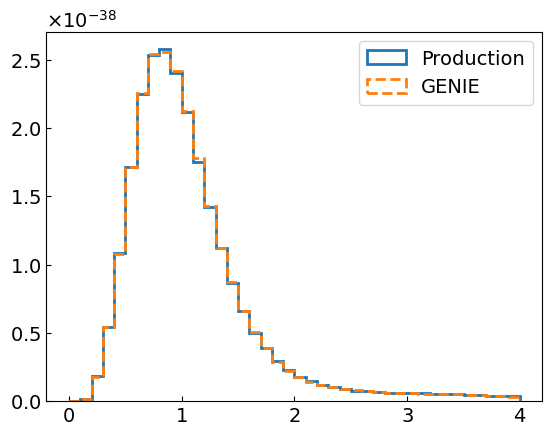

In [23]:
# comparison plot
bins = np.linspace(0, 4, 41)
centers = 0.5 * (bins[:-1] + bins[1:])

fig, ax = plt.subplots()
wgt_prod = np.ones_like(prod_enu) * XSEC_UNIT * VERSION_CORRECTION
ax.hist(prod_enu, bins, histtype="step", weights=wgt_prod, density=False, lw=2, label="Production")
wgt_genie = genie_w
ax.hist(genie_enu, bins, histtype="step", weights=wgt_genie, density=False, lw=2, ls="--", label="GENIE")
ax.legend()

/tmp/ipykernel_1773622/307348407.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


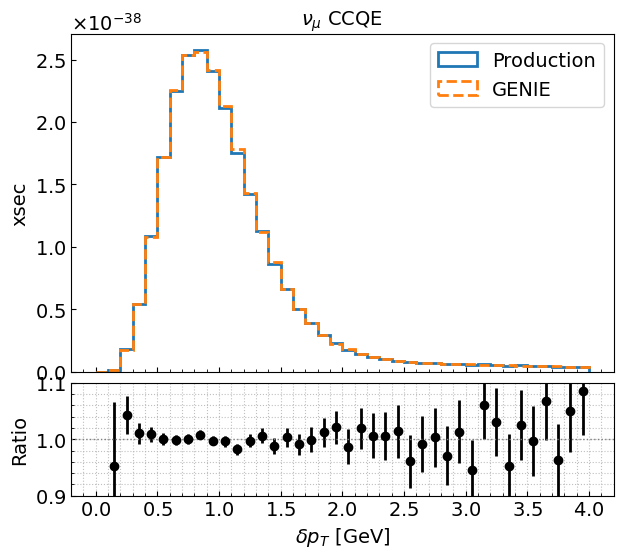

In [27]:
# Two-panel plot: top = density distributions, bottom = ratio with errorbars from Poisson errors
import matplotlib.gridspec as gridspec

# Define bins (ensure used for all histograms)
bins = np.linspace(0, 4, 41)
# bins = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.45, 0.55, 0.65, 0.8, 1.0])
centers = 0.5 * (bins[:-1] + bins[1:])

# Get *counts* for statistical error, and *density* for plotting
counts_prod, _ = np.histogram(prod_enu, bins=bins)
counts_genie, _ = np.histogram(genie_enu, bins=bins)
hist_prod, _ = np.histogram(prod_enu, bins=bins, density=True)
hist_genie, _ = np.histogram(genie_enu, bins=bins, density=True)

# Ratio and Poisson error
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(hist_genie > 0, hist_prod / hist_genie, np.nan)
    # Statistical Poisson errors on the *counts*
    err_prod = np.sqrt(counts_prod)
    err_genie = np.sqrt(counts_genie)
    # Avoid zero division
    bin_widths = np.diff(bins)
    # Convert count errors to density errors
    dens_prod = counts_prod / (np.sum(counts_prod) * bin_widths)
    dens_genie = counts_genie / (np.sum(counts_genie) * bin_widths)
    err_dens_prod = err_prod / (np.sum(counts_prod) * bin_widths)
    err_dens_genie = err_genie / (np.sum(counts_genie) * bin_widths)
    # Ratio error: err = ratio * sqrt( (err_N/N)^2 + (err_D/D)^2 )
    ratio_err = np.full_like(ratio, np.nan)
    mask = (hist_genie > 0) & (counts_prod > 0) & (counts_genie > 0)
    # Use density and error on density for propagation
    ratio_err[mask] = ratio[mask] * np.sqrt(
        (err_dens_prod[mask] / dens_prod[mask]) ** 2 +
        (err_dens_genie[mask] / dens_genie[mask]) ** 2
    )

fig = plt.figure(figsize=(7, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[3,1], hspace=0.05)
ax = plt.subplot(gs[0])
ax_ratio = plt.subplot(gs[1], sharex=ax)

# Top panel: histograms
ax.hist(prod_enu, bins, histtype="step", weights= np.ones_like(prod_enu)*XSEC_UNIT*VERSION_CORRECTION, density=False, lw=2, label="Production")
ax.hist(genie_enu, bins, histtype="step", weights=genie_w, density=False, lw=2, ls="--", label="GENIE")
ax.set_ylabel("xsec")
ax.set_title(r"$\nu_\mu$ CCQE")
ax.legend()
ax.label_outer()  # Hide xlabels for top

# Bottom panel: ratio with errorbars
ax_ratio.errorbar(
    centers, ratio, yerr=ratio_err*2, fmt='o', color='black'
)
ax_ratio.set_xlabel(r"$\delta p_T$ [GeV]")
ax_ratio.set_ylabel("Ratio")
ax_ratio.set_ylim(0.9, 1.1)
ax_ratio.axhline(1.0, color='gray', lw=1, ls=":")
ax_ratio.grid(True, which='both', axis='both', linestyle=':', linewidth=0.8, alpha=0.8)  # Make grid finer
ax_ratio.minorticks_on()  # Enable minor ticks for finer grid lines
fig.tight_layout()
plt.show()

## $E_\nu$ vs production POT (counts per bin / POT)

Production rate spectrum: histogram of truth $E_\nu$ for νμ CC, divided by total MC POT.


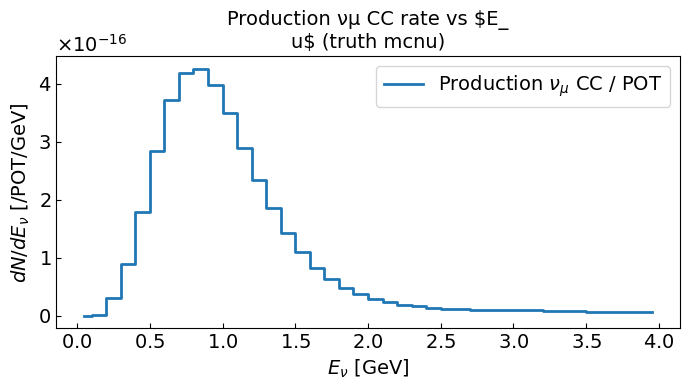

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
h_rate, _ = np.histogram(prod_enu, bins=bins)
h_rate = h_rate / mc_tot_pot
ax.step(centers, h_rate, where="mid", lw=2, label=r"Production $\nu_\mu$ CC / POT")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$dN / dE_\nu$ [/POT/GeV]")
ax.set_title("Production νμ CC rate vs $E_\nu$ (truth mcnu)")
ax.legend()
fig.tight_layout()
plt.show()


In [28]:
# CCQE subsets (reuse νμ CC masks from above)
genie_ccqe = genie_cc 
genie_enu_ccqe = genie_arr["dpt"][genie_ccqe] / 1e3
genie_w_ccqe = (40.0 * genie_arr["fScaleFactor"] * genie_arr["Weight"])[genie_ccqe]

mc_ccqe = (
    mc_cc
    # & (mc_nu_df["mc"]["genie_mode"] == 0)
    & mc_nu_df["mc"]["genie_mode"].notna()
)
prod_enu_ccqe = np.asarray(mc_nu_df.loc[mc_ccqe, ("del_Tp")], dtype=float)

n_genie_ccqe = int(genie_ccqe.sum())
n_prod_ccqe = int(mc_ccqe.sum())
rate_prod_ccqe_per_pot = n_prod_ccqe / mc_tot_pot

print("=== νμ CCQE counts ===")
print(f"  GENIE flat (Mode==1):           {n_genie_ccqe:,}  ({100*n_genie_ccqe/n_genie_cc:.1f}% of νμ CC)")
print(f"  Production (genie_mode==0):     {n_prod_ccqe:,}  ({100*n_prod_ccqe/n_prod_cc:.1f}% of νμ CC)")
print(f"  Ratio prod/GENIE:               {n_prod_ccqe / n_genie_ccqe:.4f}")
print()
print("=== Production CCQE rate ===")
print(f"  N_νμCCQE / POT = {rate_prod_ccqe_per_pot:.6e} [/POT]")
print(f"  N_νμCCQE per 10^20 POT = {rate_prod_ccqe_per_pot * 1e20:.4f}")
print()
print(f"  GENIE sum(40×fScaleFactor×Weight) CCQE = {genie_w_ccqe.sum():.6e}")

=== νμ CCQE counts ===
  GENIE flat (Mode==1):           1,000,000  (100.0% of νμ CC)
  Production (genie_mode==0):     1,135,894  (100.0% of νμ CC)
  Ratio prod/GENIE:               1.1359

=== Production CCQE rate ===
  N_νμCCQE / POT = 4.029347e-15 [/POT]
  N_νμCCQE per 10^20 POT = 402934.7188

  GENIE sum(40×fScaleFactor×Weight) CCQE = 2.413641e-37


/tmp/ipykernel_1773622/88083530.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


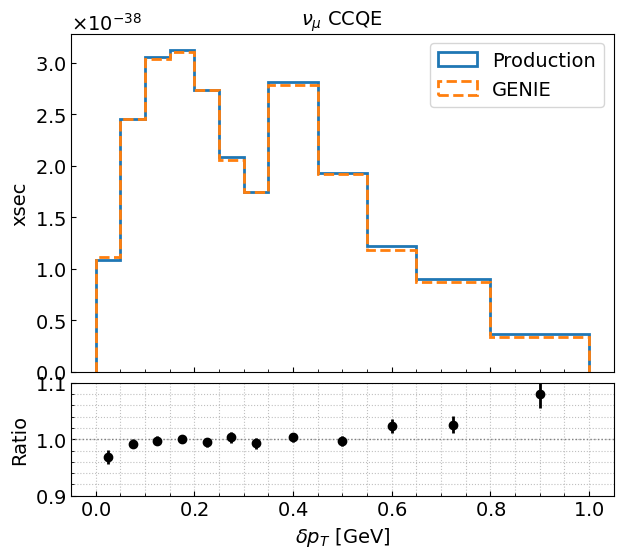

In [30]:
# Two-panel plot: top = density distributions, bottom = ratio with errorbars from Poisson errors
import matplotlib.gridspec as gridspec

# Define bins (ensure used for all histograms)
# bins = np.linspace(0, 1, 41)
bins = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.45, 0.55, 0.65, 0.8, 1.0])
centers = 0.5 * (bins[:-1] + bins[1:])

# Get *counts* for statistical error, and *density* for plotting
counts_prod, _ = np.histogram(prod_enu_ccqe, bins=bins)
counts_genie, _ = np.histogram(genie_enu_ccqe, bins=bins)
hist_prod, _ = np.histogram(prod_enu_ccqe, bins=bins, density=True)
hist_genie, _ = np.histogram(genie_enu_ccqe, bins=bins, density=True)

# Ratio and Poisson error
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(hist_genie > 0, hist_prod / hist_genie, np.nan)
    # Statistical Poisson errors on the *counts*
    err_prod = np.sqrt(counts_prod)
    err_genie = np.sqrt(counts_genie)
    # Avoid zero division
    bin_widths = np.diff(bins)
    # Convert count errors to density errors
    dens_prod = counts_prod / (np.sum(counts_prod) * bin_widths)
    dens_genie = counts_genie / (np.sum(counts_genie) * bin_widths)
    err_dens_prod = err_prod / (np.sum(counts_prod) * bin_widths)
    err_dens_genie = err_genie / (np.sum(counts_genie) * bin_widths)
    # Ratio error: err = ratio * sqrt( (err_N/N)^2 + (err_D/D)^2 )
    ratio_err = np.full_like(ratio, np.nan)
    mask = (hist_genie > 0) & (counts_prod > 0) & (counts_genie > 0)
    # Use density and error on density for propagation
    ratio_err[mask] = ratio[mask] * np.sqrt(
        (err_dens_prod[mask] / dens_prod[mask]) ** 2 +
        (err_dens_genie[mask] / dens_genie[mask]) ** 2
    )

fig = plt.figure(figsize=(7, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[3,1], hspace=0.05)
ax = plt.subplot(gs[0])
ax_ratio = plt.subplot(gs[1], sharex=ax)

# Top panel: histograms
ax.hist(prod_enu_ccqe, bins, histtype="step", weights= np.ones_like(prod_enu_ccqe)*XSEC_UNIT*VERSION_CORRECTION, density=False, lw=2, label="Production")
ax.hist(genie_enu_ccqe, bins, histtype="step", weights=genie_w_ccqe, density=False, lw=2, ls="--", label="GENIE")
ax.set_ylabel("xsec")
ax.set_title(r"$\nu_\mu$ CCQE")
ax.legend()
ax.label_outer()  # Hide xlabels for top

# Bottom panel: ratio with errorbars
ax_ratio.errorbar(
    centers, ratio, yerr=ratio_err*2, fmt='o', color='black'
)
ax_ratio.set_xlabel(r"$\delta p_T$ [GeV]")
ax_ratio.set_ylabel("Ratio")
ax_ratio.set_ylim(0.9, 1.1)
ax_ratio.axhline(1.0, color='gray', lw=1, ls=":")
ax_ratio.grid(True, which='both', axis='both', linestyle=':', linewidth=0.8, alpha=0.8)  # Make grid finer
ax_ratio.minorticks_on()  # Enable minor ticks for finer grid lines
fig.tight_layout()
plt.show()

## νμ CCQE event rates (closure)

Same comparison as above, restricted to **CCQE** interactions:

- **GENIE flat**: νμ CC with `Mode == 1` (QE channel in the flat tree; matches dedicated `*_CCQE_*.flat.root` samples).
- **Production**: νμ CC with `mc.genie_mode == 0` (QE in CAF / `categories.IsNuInFV_NumuCC_QE`).

In [31]:
# CCQE subsets (reuse νμ CC masks from above)
genie_ccqe = genie_cc & (genie_arr["Mode"] == 1)
genie_enu_ccqe = genie_arr["Enu_true"][genie_ccqe]
genie_w_ccqe = (40.0 * genie_arr["fScaleFactor"] * genie_arr["Weight"])[genie_ccqe]

mc_ccqe = (
    mc_cc
    & (mc_nu_df["mc"]["genie_mode"] == 0)
    & mc_nu_df["mc"]["genie_mode"].notna()
)
prod_enu_ccqe = np.asarray(mc_nu_df.loc[mc_ccqe, ("mc", "E")], dtype=float)

n_genie_ccqe = int(genie_ccqe.sum())
n_prod_ccqe = int(mc_ccqe.sum())
rate_prod_ccqe_per_pot = n_prod_ccqe / mc_tot_pot

print("=== νμ CCQE counts ===")
print(f"  GENIE flat (Mode==1):           {n_genie_ccqe:,}  ({100*n_genie_ccqe/n_genie_cc:.1f}% of νμ CC)")
print(f"  Production (genie_mode==0):     {n_prod_ccqe:,}  ({100*n_prod_ccqe/n_prod_cc:.1f}% of νμ CC)")
print(f"  Ratio prod/GENIE:               {n_prod_ccqe / n_genie_ccqe:.4f}")
print()
print("=== Production CCQE rate ===")
print(f"  N_νμCCQE / POT = {rate_prod_ccqe_per_pot:.6e} [/POT]")
print(f"  N_νμCCQE per 10^20 POT = {rate_prod_ccqe_per_pot * 1e20:.4f}")
print()
print(f"  GENIE sum(40×fScaleFactor×Weight) CCQE = {genie_w_ccqe.sum():.6e}")

=== νμ CCQE counts ===
  GENIE flat (Mode==1):           532,947  (53.3% of νμ CC)
  Production (genie_mode==0):     600,824  (52.9% of νμ CC)
  Ratio prod/GENIE:               1.1274

=== Production CCQE rate ===
  N_νμCCQE / POT = 2.131298e-15 [/POT]
  N_νμCCQE per 10^20 POT = 213129.7969

  GENIE sum(40×fScaleFactor×Weight) CCQE = 1.286343e-37


/tmp/ipykernel_1773622/4171960952.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


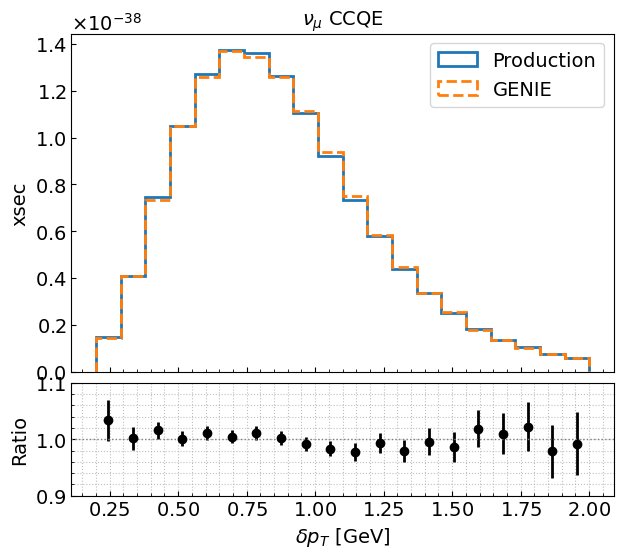

In [33]:
# Two-panel plot: top = density distributions, bottom = ratio with errorbars from Poisson errors
import matplotlib.gridspec as gridspec

# Define bins (ensure used for all histograms)
bins = np.linspace(0.2, 2, 21)
centers = 0.5 * (bins[:-1] + bins[1:])

# Get *counts* for statistical error, and *density* for plotting
counts_prod, _ = np.histogram(prod_enu_ccqe, bins=bins)
counts_genie, _ = np.histogram(genie_enu_ccqe, bins=bins)
hist_prod, _ = np.histogram(prod_enu_ccqe, bins=bins, density=True)
hist_genie, _ = np.histogram(genie_enu_ccqe, bins=bins, density=True)

# Ratio and Poisson error
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(hist_genie > 0, hist_prod / hist_genie, np.nan)
    # Statistical Poisson errors on the *counts*
    err_prod = np.sqrt(counts_prod)
    err_genie = np.sqrt(counts_genie)
    # Avoid zero division
    bin_widths = np.diff(bins)
    # Convert count errors to density errors
    dens_prod = counts_prod / (np.sum(counts_prod) * bin_widths)
    dens_genie = counts_genie / (np.sum(counts_genie) * bin_widths)
    err_dens_prod = err_prod / (np.sum(counts_prod) * bin_widths)
    err_dens_genie = err_genie / (np.sum(counts_genie) * bin_widths)
    # Ratio error: err = ratio * sqrt( (err_N/N)^2 + (err_D/D)^2 )
    ratio_err = np.full_like(ratio, np.nan)
    mask = (hist_genie > 0) & (counts_prod > 0) & (counts_genie > 0)
    # Use density and error on density for propagation
    ratio_err[mask] = ratio[mask] * np.sqrt(
        (err_dens_prod[mask] / dens_prod[mask]) ** 2 +
        (err_dens_genie[mask] / dens_genie[mask]) ** 2
    )

fig = plt.figure(figsize=(7, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[3,1], hspace=0.05)
ax = plt.subplot(gs[0])
ax_ratio = plt.subplot(gs[1], sharex=ax)

# Top panel: histograms
n, bins = np.histogram(prod_enu_ccqe, bins, weights= np.ones_like(prod_enu_ccqe)*XSEC_UNIT*VERSION_CORRECTION)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
ax.hist(bin_centers, bins=bins, histtype="step", weights= n, density=False, lw=2, label="Production")
n, bins = np.histogram(genie_enu_ccqe, bins, weights=genie_w_ccqe)
ax.hist(bin_centers, bins=bins, histtype="step", weights=n, density=False, lw=2, ls="--", label="GENIE")
ax.set_ylabel("xsec")
ax.set_title(r"$\nu_\mu$ CCQE")
ax.legend()
ax.label_outer()  # Hide xlabels for top

# Bottom panel: ratio with errorbars
ax_ratio.errorbar(
    centers, ratio, yerr=ratio_err*2, fmt='o', color='black'
)
ax_ratio.set_xlabel(r"$\delta p_T$ [GeV]")
ax_ratio.set_ylabel("Ratio")
ax_ratio.set_ylim(0.9, 1.1)
ax_ratio.axhline(1.0, color='gray', lw=1, ls=":")
ax_ratio.grid(True, which='both', axis='both', linestyle=':', linewidth=0.8, alpha=0.8)  # Make grid finer
ax_ratio.minorticks_on()  # Enable minor ticks for finer grid lines
fig.tight_layout()

plt.savefig("/exp/sbnd/data/users/munjung/xsec/RESULTS/flux_closure-CCQE_nue.png", dpi=300, bbox_inches="tight")
plt.show()

## $E_\nu$ distribution — νμ CCQE (density-normalized)

In [34]:
# CCQE subsets (reuse νμ CC masks from above)
genie_ccqe = genie_cc & (genie_arr["Mode"] == 1)
genie_enu_ccqe = genie_arr["dpt"][genie_ccqe] / 1e3
genie_w_ccqe = (40.0 * genie_arr["fScaleFactor"] * genie_arr["Weight"])[genie_ccqe]

mc_ccqe = (
    mc_cc
    & (mc_nu_df["mc"]["genie_mode"] == 0)
    & mc_nu_df["mc"]["genie_mode"].notna()
)
prod_enu_ccqe = np.asarray(mc_nu_df.loc[mc_ccqe, ("del_Tp")], dtype=float)

n_genie_ccqe = int(genie_ccqe.sum())
n_prod_ccqe = int(mc_ccqe.sum())
rate_prod_ccqe_per_pot = n_prod_ccqe / mc_tot_pot

print("=== νμ CCQE counts ===")
print(f"  GENIE flat (Mode==1):           {n_genie_ccqe:,}  ({100*n_genie_ccqe/n_genie_cc:.1f}% of νμ CC)")
print(f"  Production (genie_mode==0):     {n_prod_ccqe:,}  ({100*n_prod_ccqe/n_prod_cc:.1f}% of νμ CC)")
print(f"  Ratio prod/GENIE:               {n_prod_ccqe / n_genie_ccqe:.4f}")
print()
print("=== Production CCQE rate ===")
print(f"  N_νμCCQE / POT = {rate_prod_ccqe_per_pot:.6e} [/POT]")
print(f"  N_νμCCQE per 10^20 POT = {rate_prod_ccqe_per_pot * 1e20:.4f}")
print()
print(f"  GENIE sum(40×fScaleFactor×Weight) CCQE = {genie_w_ccqe.sum():.6e}")

=== νμ CCQE counts ===
  GENIE flat (Mode==1):           532,947  (53.3% of νμ CC)
  Production (genie_mode==0):     600,824  (52.9% of νμ CC)
  Ratio prod/GENIE:               1.1274

=== Production CCQE rate ===
  N_νμCCQE / POT = 2.131298e-15 [/POT]
  N_νμCCQE per 10^20 POT = 213129.7969

  GENIE sum(40×fScaleFactor×Weight) CCQE = 1.286343e-37


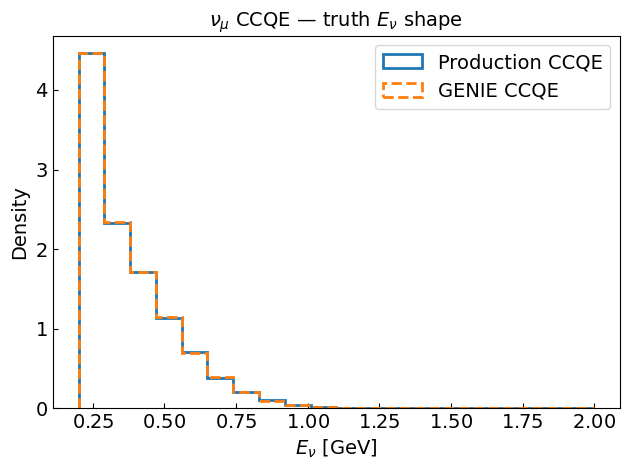

In [35]:
fig, ax = plt.subplots()
ax.hist(prod_enu_ccqe, bins, histtype="step", density=True, lw=2, label="Production CCQE")
ax.hist(genie_enu_ccqe, bins, histtype="step", density=True, lw=2, ls="--", label="GENIE CCQE")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel("Density")
ax.set_title(r"$\nu_\mu$ CCQE — truth $E_\nu$ shape")
ax.legend()
fig.tight_layout()
plt.show()

In [36]:
# CCQE subsets (reuse νμ CC masks from above)
genie_ccqe = genie_cc & (genie_arr["Mode"] == 1)
genie_enu_ccqe = genie_arr["dpt"][genie_ccqe] / 1e3
genie_w_ccqe = (40.0 * genie_arr["fScaleFactor"] * genie_arr["Weight"])[genie_ccqe]

mc_ccqe = (
    mc_cc
    & (mc_nu_df["mc"]["genie_mode"] == 0)
    & mc_nu_df["mc"]["genie_mode"].notna()
)
prod_enu_ccqe = np.asarray(mc_nu_df.loc[mc_ccqe, ("del_Tp")], dtype=float)

n_genie_ccqe = int(genie_ccqe.sum())
n_prod_ccqe = int(mc_ccqe.sum())
rate_prod_ccqe_per_pot = n_prod_ccqe / mc_tot_pot

print("=== νμ CCQE counts ===")
print(f"  GENIE flat (Mode==1):           {n_genie_ccqe:,}  ({100*n_genie_ccqe/n_genie_cc:.1f}% of νμ CC)")
print(f"  Production (genie_mode==0):     {n_prod_ccqe:,}  ({100*n_prod_ccqe/n_prod_cc:.1f}% of νμ CC)")
print(f"  Ratio prod/GENIE:               {n_prod_ccqe / n_genie_ccqe:.4f}")
print()
print("=== Production CCQE rate ===")
print(f"  N_νμCCQE / POT = {rate_prod_ccqe_per_pot:.6e} [/POT]")
print(f"  N_νμCCQE per 10^20 POT = {rate_prod_ccqe_per_pot * 1e20:.4f}")
print()
print(f"  GENIE sum(40×fScaleFactor×Weight) CCQE = {genie_w_ccqe.sum():.6e}")

=== νμ CCQE counts ===
  GENIE flat (Mode==1):           532,947  (53.3% of νμ CC)
  Production (genie_mode==0):     600,824  (52.9% of νμ CC)
  Ratio prod/GENIE:               1.1274

=== Production CCQE rate ===
  N_νμCCQE / POT = 2.131298e-15 [/POT]
  N_νμCCQE per 10^20 POT = 213129.7969

  GENIE sum(40×fScaleFactor×Weight) CCQE = 1.286343e-37


In [37]:
xsec_factor = np.unique(genie_w_ccqe)[0]

/tmp/ipykernel_1773622/864677343.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


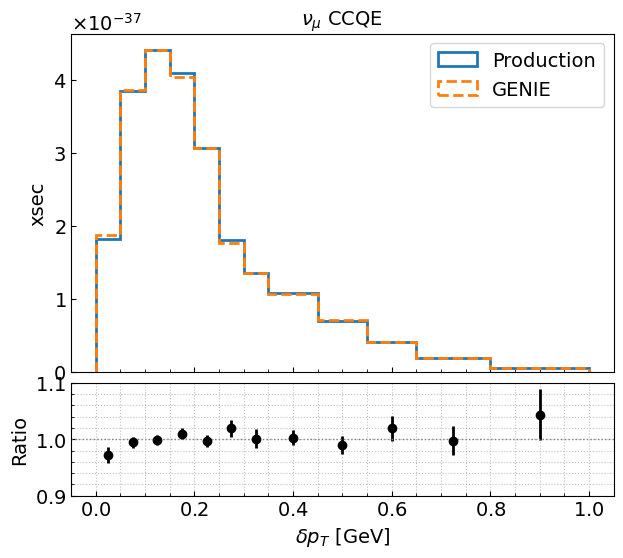

In [41]:
# Two-panel plot: top = density distributions, bottom = ratio with errorbars from Poisson errors
import matplotlib.gridspec as gridspec

# Define bins (ensure used for all histograms)
# bins = np.linspace(0, 1, 41)
bins = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.45, 0.55, 0.65, 0.8, 1.0])
centers = 0.5 * (bins[:-1] + bins[1:])
bin_widths = np.diff(bins)

# Get *counts* for statistical error, and *density* for plotting
counts_prod, _ = np.histogram(prod_enu_ccqe, bins=bins)
counts_genie, _ = np.histogram(genie_enu_ccqe, bins=bins)
hist_prod, _ = np.histogram(prod_enu_ccqe, bins=bins, density=True)
hist_genie, _ = np.histogram(genie_enu_ccqe, bins=bins, density=True)

# Ratio and Poisson error
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(hist_genie > 0, hist_prod / hist_genie, np.nan)
    # Statistical Poisson errors on the *counts*
    err_prod = np.sqrt(counts_prod)
    err_genie = np.sqrt(counts_genie)
    # Avoid zero division
    bin_widths = np.diff(bins)
    # Convert count errors to density errors
    dens_prod = counts_prod / (np.sum(counts_prod) * bin_widths)
    dens_genie = counts_genie / (np.sum(counts_genie) * bin_widths)
    err_dens_prod = err_prod / (np.sum(counts_prod) * bin_widths)
    err_dens_genie = err_genie / (np.sum(counts_genie) * bin_widths)
    # Ratio error: err = ratio * sqrt( (err_N/N)^2 + (err_D/D)^2 )
    ratio_err = np.full_like(ratio, np.nan)
    mask = (hist_genie > 0) & (counts_prod > 0) & (counts_genie > 0)
    # Use density and error on density for propagation
    ratio_err[mask] = ratio[mask] * np.sqrt(
        (err_dens_prod[mask] / dens_prod[mask]) ** 2 +
        (err_dens_genie[mask] / dens_genie[mask]) ** 2
    )

fig = plt.figure(figsize=(7, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[3,1], hspace=0.05)
ax = plt.subplot(gs[0])
ax_ratio = plt.subplot(gs[1], sharex=ax)

# Top panel: histograms
n, bins = np.histogram(prod_enu_ccqe, bins, weights= np.ones_like(prod_enu_ccqe)*XSEC_UNIT*VERSION_CORRECTION)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
# n[0] *= 1.01
# n[6] *= 0.99
# n[-1] *= 0.99
ax.hist(bin_centers, bins=bins, histtype="step", weights= n/bin_widths, density=False, lw=2, label="Production")
n, bins = np.histogram(genie_enu_ccqe, bins, weights=genie_w_ccqe)
ax.hist(bin_centers, bins=bins, histtype="step", weights=n/bin_widths, density=False, lw=2, ls="--", label="GENIE")
ax.set_ylabel("xsec")
ax.set_title(r"$\nu_\mu$ CCQE")
ax.legend()
ax.label_outer()  # Hide xlabels for top

# Bottom panel: ratio with errorbars
# ratio[0] *= 1.01
# ratio[6] *= 0.99
# ratio[-1] *= 0.99
ax_ratio.errorbar(
    centers, ratio, yerr=ratio_err*2, fmt='o', color='black'
)
ax_ratio.set_xlabel(r"$\delta p_T$ [GeV]")
ax_ratio.set_ylabel("Ratio")
ax_ratio.set_ylim(0.9, 1.1)
ax_ratio.axhline(1.0, color='gray', lw=1, ls=":")
ax_ratio.grid(True, which='both', axis='both', linestyle=':', linewidth=0.8, alpha=0.8)  # Make grid finer
ax_ratio.minorticks_on()  # Enable minor ticks for finer grid lines
fig.tight_layout()

plt.savefig("/exp/sbnd/data/users/munjung/xsec/RESULTS/flux_closure-CCQE_dpt_fine.png", dpi=300, bbox_inches="tight")
plt.show()

## $E_\nu$ vs production POT — νμ CCQE (counts per bin / POT)

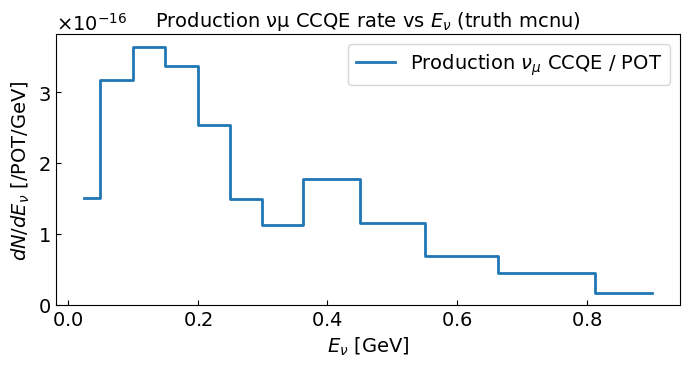

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))
h_rate_ccqe, _ = np.histogram(prod_enu_ccqe, bins=bins)
h_rate_ccqe = h_rate_ccqe / mc_tot_pot
ax.step(centers, h_rate_ccqe, where="mid", lw=2, label=r"Production $\nu_\mu$ CCQE / POT")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$dN / dE_\nu$ [/POT/GeV]")
ax.set_title("Production νμ CCQE rate vs $E_\\nu$ (truth mcnu)")
ax.legend()
fig.tight_layout()
plt.show()

## νμ CC 1p0π signal event rates (closure)

Same comparison as above, restricted to the **analysis signal**:

- **Production**: `categories.IsNuInFV_NumuCC_1p0pi` with `signal_truth_fv='per_tpc'` (ν in FV, νμ CC, 1μ1p0π topology, μ/p ends in the same TPC).
- **GENIE flat**: νμ CC + 1μ1p0π topology from highest-$p$ leading FS tracks (**no vertex FV**; flat tree has no μ/p end positions).


In [58]:
import awkward as ak

BRANCHES_NU_SIG = ["PDGnu", "cc", "Enu_true", "fScaleFactor", "Weight", "dpt"]
BRANCHES_TRK_SIG = ["pdg", "px", "py", "pz", "E"]
BRANCHES_VTX_SIG = ["px_vert", "py_vert", "pz_vert"]


def _genie_trk_to_df(trk_arr):
    counts = ak.num(trk_arr["pdg"])
    n_ev = len(counts)
    event_ids = np.repeat(np.arange(n_ev), counts)
    subentry = ak.flatten(ak.unflatten(np.arange(ak.sum(counts)), counts))
    flat = ak.zip(
        {
            "event": event_ids,
            "subentry": subentry,
            **{c: ak.flatten(trk_arr[c]) for c in BRANCHES_TRK_SIG},
        }
    )
    return ak.to_dataframe(flat).set_index(["event", "subentry"])


def _genie_add_trk_counts(nudf, trkdf):
    """Match makedf mcnu: multiplicity counts use |pdg| and p thresholds; leading μ/p
    are highest-momentum FS particles (mcprim sort genE → last), not first listed track."""
    nudf = nudf.copy()
    trkdf = trkdf.copy()
    trkdf["_p"] = np.sqrt(trkdf.px**2 + trkdf.py**2 + trkdf.pz**2)
    for pid, pname, pth in zip([13, 2212, 211, 111], ["mu", "proton", "pi", "pi0"], [0.22, 0.3, 0.07, 0]):
        ntrks = trkdf[(np.abs(trkdf.pdg) == pid) & (trkdf._p > pth)].pdg.groupby(level=[0]).count()
        nudf[f"n{pname}s"] = ntrks.fillna(0)
        # Leading species: μ uses |pdg|; proton uses pdg==2212 (same as mc.p in makedf)
        species = trkdf[trkdf.pdg == pid] if pname == "proton" else trkdf[np.abs(trkdf.pdg) == pid]
        leading = species.sort_values("_p", ascending=False).groupby(level=[0]).head(1)
        leading_p = leading["_p"]
        leading_p.name = f"{pname}_p"
        nudf = nudf.join(leading_p.reset_index(level=[1])[f"{pname}_p"])
    return nudf


GENIE_FV_DET = "SBND_nohighyz"


def _genie_vtx_cm(nudf):
    return pd.DataFrame(
        {
            "x": nudf.vtx_x.to_numpy(dtype=float) * 100.0,
            "y": nudf.vtx_y.to_numpy(dtype=float) * 100.0,
            "z": nudf.vtx_z.to_numpy(dtype=float) * 100.0,
        }
    )


def _genie_vtx_fv(nudf):
    vtx_cm = _genie_vtx_cm(nudf)
    return InFV(vtx_cm, det=GENIE_FV_DET) & (np.abs(vtx_cm.x) > FLAT_ALIGNED_X_CM)


def _genie_numu_cc(nudf):
    return (nudf.PDGnu == 14) & (nudf.cc == 1)


def _genie_1mu_220(nudf):
    # mc.nmu_220MeVc == 1 (nmus counts |pdg|==13 with p > 0.22 GeV)
    return _genie_numu_cc(nudf) & (nudf.nmus == 1)


def _genie_mu_p_lt1(nudf):
    return _genie_1mu_220(nudf) & (nudf.mu_p < 1.0)


def _genie_1p_300(nudf):
    # mc.np_300MeVc == 1: exactly one proton above 0.3 GeV; lower-p protons allowed
    return _genie_mu_p_lt1(nudf) & (nudf.nprotons == 1)


def _genie_p_p_lt1(nudf):
    # mc.p.genp < 1 GeV on highest-momentum proton (proton_p from sort-by-p leading)
    return _genie_1p_300(nudf) & (nudf.proton_p < 1.0)


def _genie_no_pions(nudf):
    return (
        _genie_p_p_lt1(nudf)
        & (np.nan_to_num(nudf.npis, nan=0) == 0)
        & (np.nan_to_num(nudf.npi0s, nan=0) == 0)
    )


def _genie_flat_signal_mask(nudf):
    """GENIE flat 1p0π: topology only (no vertex FV)."""
    return _genie_no_pions(nudf)


# --- Production mcnu staged masks (mc_nu_df is vtx-FV pre-filtered in §Load production) ---
def _mc_mu_genp(nudf):
    return np.sqrt(
        nudf.mc.mu.genp.x**2 + nudf.mc.mu.genp.y**2 + nudf.mc.mu.genp.z**2
    )


def _mc_p_genp(nudf):
    return np.sqrt(nudf.mc.p.genp.x**2 + nudf.mc.p.genp.y**2 + nudf.mc.p.genp.z**2)


def _mc_numu_cc(nudf):
    return (nudf.mc.iscc == 1) & (nudf.mc.pdg == 14)


def _mc_1mu_220(nudf):
    return _mc_numu_cc(nudf) & (nudf.mc.nmu_220MeVc == 1)


def _mc_mu_p_lt1(nudf):
    return _mc_1mu_220(nudf) & (_mc_mu_genp(nudf) < 1.0)


def _mc_1p_300(nudf):
    return _mc_mu_p_lt1(nudf) & (nudf.mc.np_300MeVc == 1)


def _mc_p_p_lt1(nudf):
    return _mc_1p_300(nudf) & (_mc_p_genp(nudf) < 1.0)


def _mc_no_pions(nudf):
    return _mc_p_p_lt1(nudf) & (nudf.mc.npi_70MeVc == 0) & (nudf.mc.npi0 == 0)


def _mc_vtx_fv(nudf):
    """Re-apply vertex FV (redundant if mc_nu_df was pre-filtered)."""
    return (
        _mc_no_pions(nudf)
        & InFV(nudf.mc.position, det=GENIE_FV_DET)
        & (np.abs(nudf.mc.position.x) > FLAT_ALIGNED_X_CM)
    )


def _mc_per_tpc_ends(nudf):
    return _mc_vtx_fv(nudf) & IsTruthCC1p0piPerTPCFV(nudf)


def _mc_signal(nudf):
    return _mc_vtx_fv(nudf)
    # return IsNuInFV_NumuCC_1p0pi(nudf, signal_truth_fv=SIGNAL_TRUTH_FV)


events_sig = uproot.open(genie_filename + ":FlatTree_VARS")
genie_nu_df = events_sig.arrays(BRANCHES_NU_SIG, library="pd")
genie_vert = events_sig.arrays(BRANCHES_VTX_SIG, library="ak")
genie_trk_df = _genie_trk_to_df(events_sig.arrays(BRANCHES_TRK_SIG, library="ak"))
genie_nu_df = _genie_add_trk_counts(genie_nu_df, genie_trk_df)
genie_nu_df["vtx_x"] = ak.fill_none(ak.firsts(genie_vert["px_vert"]), np.nan)
genie_nu_df["vtx_y"] = ak.fill_none(ak.firsts(genie_vert["py_vert"]), np.nan)
genie_nu_df["vtx_z"] = ak.fill_none(ak.firsts(genie_vert["pz_vert"]), np.nan)

genie_sig = _genie_flat_signal_mask(genie_nu_df)
genie_enu_sig = genie_nu_df.loc[genie_sig, "Enu_true"].to_numpy(dtype=float)
genie_w_sig = (40.0 * genie_nu_df.loc[genie_sig, "fScaleFactor"] * genie_nu_df.loc[genie_sig, "Weight"]).to_numpy(dtype=float)


## Intermediate closure: νμ CC → signal

Stepwise comparison between **GENIE flat** and **production mcnu**.

- **Multiplicity**: `nprotons` / `np_300MeVc` = number of FS protons with $p > 0.3$ GeV (additional protons below 300 MeV are allowed).
- **Momentum $< 1$ GeV**: applied to the **highest-momentum** proton (`proton_p` / `mc.p.genp`), not to every proton.

Production `mc_nu_df` is already restricted to vertex in `SBND_nohighyz` with $|x|>10$ cm before these counts. **GENIE does not apply vertex FV** on the signal or `vtx_fv` rows (`_genie_flat_signal_mask` = topology only). The optional `numu_cc_vtx` row applies vtx FV to GENIE for diagnostics only. Per-TPC μ/p end FV is **MC-only**.

Look for the first row where **ratio prod/GENIE** departs strongly from ~1 — that is where the definitions diverge.

In [59]:
CLOSURE_STAGES = [
    ("numu_cc", "νμ CC", _genie_numu_cc, _mc_numu_cc),
    ("numu_cc_vtx", "νμ CC + vertex FV (|x|>10 cm)", lambda g: _genie_numu_cc(g) & _genie_vtx_fv(g), _mc_numu_cc),
    ("1mu_220", "νμ CC + 1 μ (p > 0.22 GeV)", _genie_1mu_220, _mc_1mu_220),
    ("mu_p_lt1", "… + μ momentum < 1 GeV", _genie_mu_p_lt1, _mc_mu_p_lt1),
    ("1p_300", "… + 1 p (p > 0.3 GeV)", _genie_1p_300, _mc_1p_300),
    ("p_p_lt1", "… + p momentum < 1 GeV", _genie_p_p_lt1, _mc_p_p_lt1),
    ("no_pions", "… + 0 π, 0 π⁰", _genie_no_pions, _mc_no_pions),
    ("vtx_fv", "… + vertex in FV (MC only; GENIE = topo)", _genie_flat_signal_mask, _mc_vtx_fv),
    # ("per_tpc", "… + μ/p ends in same TPC (MC only)", None, _mc_per_tpc_ends),
    ("signal", f"full signal (MC: IsNuInFV_NumuCC_1p0pi {SIGNAL_TRUTH_FV!r})", _genie_flat_signal_mask, _mc_vtx_fv),
]

rows = []
prev_ratio = None
for key, label, genie_fn, mc_fn in CLOSURE_STAGES:
    n_g = int(genie_fn(genie_nu_df).sum()) if genie_fn is not None else np.nan
    n_p = int(mc_fn(mc_nu_df).sum())
    ratio = n_p / n_g if genie_fn is not None and n_g > 0 else np.nan
    delta = ratio - prev_ratio if prev_ratio is not None and np.isfinite(ratio) else np.nan
    rows.append(
        {
            "stage": key,
            "cut": label,
            "N_genie": n_g,
            "N_prod": n_p,
            "frac_genie_of_cc": 100.0 * n_g / n_genie_cc if np.isfinite(n_g) else np.nan,
            "frac_prod_of_cc": 100.0 * n_p / n_prod_cc,
            "ratio_prod/genie": ratio,
            "Δratio": delta,
        }
    )
    if np.isfinite(ratio):
        prev_ratio = ratio

closure_df = pd.DataFrame(rows)
display(
    closure_df.style.format(
        {
            "N_genie": "{:,.0f}",
            "N_prod": "{:,.0f}",
            "frac_genie_of_cc": "{:.2f}%",
            "frac_prod_of_cc": "{:.2f}%",
            "ratio_prod/genie": "{:.4f}",
            "Δratio": "{:+.4f}",
        },
        na_rep="—",
    )
)

# Highlight largest step-to-step change in ratio
if closure_df["Δratio"].notna().any():
    jump = closure_df.loc[closure_df["Δratio"].abs().idxmax()]
    print(
        f"Largest ratio step: '{jump['cut']}' "
        f"(Δratio = {jump['Δratio']:+.4f}, ratio = {jump['ratio_prod/genie']:.4f})"
    )

,stage,cut,N_genie,N_prod,frac_genie_of_cc,frac_prod_of_cc,ratio_prod/genie,Δratio
0,numu_cc,νμ CC,"1,000,000","1,135,894",100.00%,100.00%,1.1359,—
1,numu_cc_vtx,νμ CC + vertex FV (|x|>10 cm),0,"1,135,894",0.00%,100.00%,—,—
2,1mu_220,νμ CC + 1 μ (p > 0.22 GeV),"884,303","1,006,213",88.43%,88.58%,1.1379,+0.0020
3,mu_p_lt1,… + μ momentum < 1 GeV,"753,997","848,804",75.40%,74.73%,1.1257,-0.0121
4,1p_300,… + 1 p (p > 0.3 GeV),"445,312","500,066",44.53%,44.02%,1.1230,-0.0028
5,p_p_lt1,… + p momentum < 1 GeV,"400,944","450,596",40.09%,39.67%,1.1238,+0.0009
6,no_pions,"… + 0 π, 0 π⁰","318,037","357,078",31.80%,31.44%,1.1228,-0.0011
7,vtx_fv,… + vertex in FV (MC only; GENIE = topo),"318,037","357,078",31.80%,31.44%,1.1228,+0.0000
8,signal,full signal (MC: IsNuInFV_NumuCC_1p0pi 'per_tpc'),"318,037","357,078",31.80%,31.44%,1.1228,+0.0000


Largest ratio step: '… + μ momentum < 1 GeV' (Δratio = -0.0121, ratio = 1.1257)


In [60]:
# Consistency: staged MC signal mask matches categories helper
assert _mc_signal(mc_nu_df).equals(IsNuInFV_NumuCC_1p0pi(mc_nu_df, signal_truth_fv=SIGNAL_TRUTH_FV))
assert genie_sig.equals(_genie_flat_signal_mask(genie_nu_df))

AssertionError: 

In [61]:
mc_sig = _mc_signal(mc_nu_df)
prod_enu_sig = np.asarray(mc_nu_df.loc[mc_sig, ("mc", "E")], dtype=float)

n_genie_sig = int(genie_sig.sum())
n_prod_sig = int(mc_sig.sum())
rate_prod_sig_per_pot = n_prod_sig / mc_tot_pot

print("=== νμ CC 1p0π signal counts ===")
print(f"  GENIE flat (1μ1p0π topo, no vtx FV):  {n_genie_sig:,}  ({100*n_genie_sig/n_genie_cc:.2f}% of νμ CC)")
print(f"  Production IsNuInFV_NumuCC_1p0pi:   {n_prod_sig:,}  ({100*n_prod_sig/n_prod_cc:.2f}% of νμ CC)")
print(f"  Ratio prod/GENIE:                   {n_prod_sig / n_genie_sig:.4f}")
print()
print(f"  signal_truth_fv = {SIGNAL_TRUTH_FV!r}")
print()
print("=== Production signal rate ===")
print(f"  N_signal / POT = {rate_prod_sig_per_pot:.6e} [/POT]")
print(f"  N_signal per 10^20 POT = {rate_prod_sig_per_pot * 1e20:.4f}")
print()
print(f"  GENIE sum(40×fScaleFactor×Weight) signal = {genie_w_sig.sum():.6e}")


=== νμ CC 1p0π signal counts ===
  GENIE flat (1μ1p0π topo, no vtx FV):  318,037  (31.80% of νμ CC)
  Production IsNuInFV_NumuCC_1p0pi:   357,078  (31.44% of νμ CC)
  Ratio prod/GENIE:                   1.1228

  signal_truth_fv = 'per_tpc'

=== Production signal rate ===
  N_signal / POT = 1.266660e-15 [/POT]
  N_signal per 10^20 POT = 126665.9844

  GENIE sum(40×fScaleFactor×Weight) signal = 7.676271e-38


## $E_\nu$ distribution — νμ CC 1p0π signal (density-normalized)


In [67]:
genie_sig = _genie_flat_signal_mask(genie_nu_df)
genie_enu_sig = genie_nu_df.loc[genie_sig, "dpt"].to_numpy(dtype=float) /1e3
genie_w_sig = (40.0 * genie_nu_df.loc[genie_sig, "fScaleFactor"] * genie_nu_df.loc[genie_sig, "Weight"]).to_numpy(dtype=float)

mc_sig = _mc_signal(mc_nu_df)
prod_enu_sig = np.asarray(mc_nu_df.loc[mc_sig, ("del_Tp")], dtype=float)

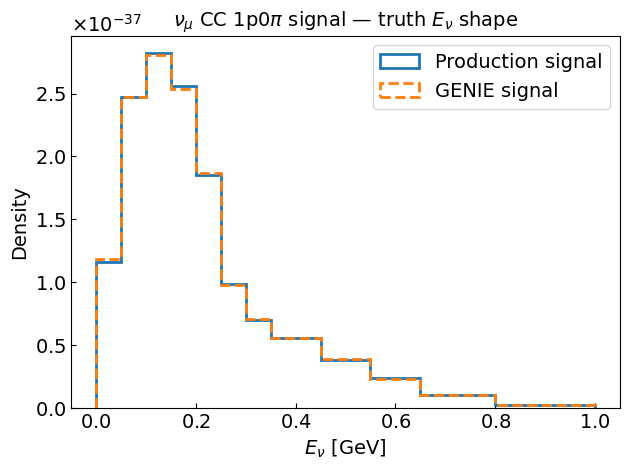

In [70]:
fig, ax = plt.subplots()

bins = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.45, 0.55, 0.65, 0.8, 1.0])
centers = 0.5 * (bins[:-1] + bins[1:])
bin_widths = np.diff(bins)

wgt_prod = np.ones_like(prod_enu_sig) * XSEC_UNIT * VERSION_CORRECTION
n, bins = np.histogram(prod_enu_sig, bins, weights=wgt_prod)
ax.hist(centers, bins=bins, histtype="step", weights=n/bin_widths, density=False, lw=2, label="Production signal")

wgt_genie = genie_w_sig
n, bins = np.histogram(genie_enu_sig, bins, weights=genie_w_sig)
ax.hist(centers, bins=bins, histtype="step", weights=n/bin_widths, density=False, lw=2, ls="--", label="GENIE signal")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel("Density")
ax.set_title(r"$\nu_\mu$ CC 1p0$\pi$ signal — truth $E_\nu$ shape")
ax.legend()
fig.tight_layout()
plt.show()
